<a href="https://colab.research.google.com/github/espartaca75-prog/Optmizacion_dinamica_discreta/blob/main/06_COD_progamaci%C3%B3n_din%C3%A1mica_Ejemplo_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ejemplo 6

---



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

In [2]:
# ---1. Configuración de Parámetros---
T = 10              # Horizonte temporal (años)
x0 = 100            # Riqueza inicial (variable de estado inicial)
beta = 0.95         # Factor de descuento (impaciencia subjetiva)
a = 1.15            # Factor de retorno del mercado (15% anual)
gamma = 0.5         # Parámetro de aversión al riesgo
A = 1.0             # Valor del coeficiente de legado final

# Diccionarios para almacenar el descubrimiento de políticas y valores
valor_funciones = {}
politicas_tasas = {}

In [3]:
#---- 2. Fase de Descubrimiento----
# Condición Terminal en T+1 (Legado)
valor_funciones[T + 1] = lambda x: A * (x**(1 - gamma))

for t in range(T, -1, -1):
    def objetivo(u, x_actual, V_futura):
        if u <= 0 or u >= x_actual: return 1e10  # Restricción: 0 < u < x
        # Utilidad inmediata + Valor futuro descontado
        utilidad_hoy = u**(1 - gamma)
        x_siguiente = a * (x_actual - u) # Dinámica del sistema
        return -(utilidad_hoy + beta * V_futura(x_siguiente))

    # El optimizador busca la tasa óptima u/x
    res = minimize_scalar(objetivo, bounds=(0, 1), args=(1.0, valor_funciones[t + 1]), method='bounded')
    tasa_optima = res.x
    politicas_tasas[t] = tasa_optima

    # Actualización de la función de valor para el periodo anterior
    valor_funciones[t] = lambda x, t=t, tasa=tasa_optima: ( (x*tasa)**(1-gamma) +
                         beta * valor_funciones[t+1](a * (x - x*tasa)) )

In [4]:
# ----3. Fase de Ejecución (Trayectoria Óptima)----
x_trayectoria = [x0]
u_trayectoria = []

for t in range(T + 1):
    x_t = x_trayectoria[-1]
    u_t = politicas_tasas[t] * x_t  # Aplicación de la política descubierta
    u_trayectoria.append(u_t)

    if t < T:
        x_next = a * (x_t - u_t) # Evolución del estado
        x_trayectoria.append(x_next)

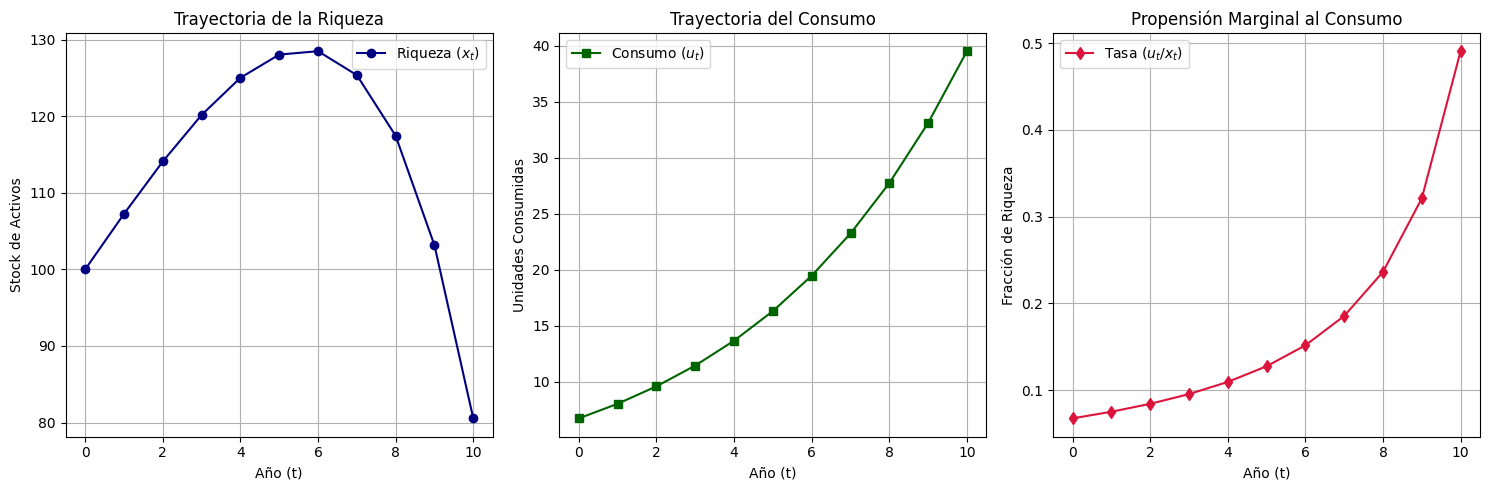

In [5]:
# ----4. Generación de Gráficas ----
plt.figure(figsize=(15, 5))

# Gráfica 1: Trayectoria de la Riqueza (Variable de Estado)
plt.subplot(1, 3, 1)
plt.plot(range(T + 1), x_trayectoria, 'o-', color='navy', label='Riqueza ($x_t$)')
plt.title('Trayectoria de la Riqueza')
plt.xlabel('Año (t)')
plt.ylabel('Stock de Activos')
plt.grid(True)
plt.legend()

# Gráfica 2: Trayectoria del Consumo (Variable de Control)
plt.subplot(1, 3, 2)
plt.plot(range(T + 1), u_trayectoria, 's-', color='darkgreen', label='Consumo ($u_t$)')
plt.title('Trayectoria del Consumo')
plt.xlabel('Año (t)')
plt.ylabel('Unidades Consumidas')
plt.grid(True)
plt.legend()

# Gráfica 3: Tasa de Consumo (Propensión Marginal) -
tasa_consumo = [u/x for u, x in zip(u_trayectoria, x_trayectoria)]
plt.subplot(1, 3, 3)
plt.plot(range(T + 1), tasa_consumo, 'd-', color='crimson', label='Tasa ($u_t/x_t$)')
plt.title('Propensión Marginal al Consumo')
plt.xlabel('Año (t)')
plt.ylabel('Fracción de Riqueza')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [6]:
# generamos una tabla de resultados
legado_final=a * (x_trayectoria[-1] - u_trayectoria[-1])
df_res = pd.DataFrame({
    'Año': range(T + 2),
    'Riqueza (xt)': x_trayectoria + [legado_final],
    'Consumo (ut)': u_trayectoria + [None],
    'Tasa de Consumo (ut/xt)': [u/x for u, x in zip(u_trayectoria, x_trayectoria)]+ [None]
})
df_res

,Año,Riqueza (xt),Consumo (ut),Tasa de Consumo (ut/xt)
0,0,100.000000,6.736797,0.067368
1,1,107.252684,8.040569,0.074968
2,2,114.093932,9.597088,0.084116
3,3,120.171371,11.454613,0.095319
4,4,125.024272,13.671680,0.109352
5,5,128.055481,16.317980,0.127429
6,6,128.498126,19.476382,0.151569
7,7,125.375006,23.245999,0.185412
8,8,117.448357,27.745630,0.236237
9,9,103.158136,33.115958,0.321021


In [7]:
# ----- Consistencia Analítica vs Numérica-----
# 1. Cálculo Analítico de Coeficientes
C_analitico = {T + 1: A}
c_analitico = {}
tasa_analitica = {}

for t in range(T, -1, -1):
    # Aplicamos la fórmula descubierta: c_t = (beta * C_t+1 * a^(1-gamma))^(1/gamma)
    termino_futuro = beta * C_analitico[t+1] * (a**(1 - gamma))
    c_t = termino_futuro**(1/gamma)
    c_analitico[t] = c_t

    # El coeficiente de valor se actualiza: C_t = (1 + c_t)^gamma
    C_analitico[t] = (1 + c_t)**gamma

    # La tasa de consumo analítica es 1 / (1 + c_t)
    tasa_analitica[t] = 1 / (1 + c_t)

# 2. Comparación de Resultados
comparativa = []
for t in range(T + 1):
    comparativa.append({
        'Año (t)': t,
        'Tasa Numérica (Python)': politicas_tasas[t],
        'Tasa Analítica (Fórmula)': tasa_analitica[t],
        'Error Absoluto': abs(politicas_tasas[t] - tasa_analitica[t])
    })

df_verificacion = pd.DataFrame(comparativa)
print("VERIFICACIÓN DE CONSISTENCIA INTERTEMPORAL")
print(df_verificacion.to_string(index=False))

# 3. Conclusión de la Verificación
error_max = df_verificacion['Error Absoluto'].max()
if error_max < 1e-5:
    print(f"\n CONSISTENCIA CONFIRMADA: El error máximo es {error_max:.2e}.")
    print("La inducción analítica y la optimización numérica han convergido al mismo resultado.")

VERIFICACIÓN DE CONSISTENCIA INTERTEMPORAL
 Año (t)  Tasa Numérica (Python)  Tasa Analítica (Fórmula)  Error Absoluto
       0                0.067368                  0.067368    4.197449e-07
       1                0.074968                  0.074970    1.152555e-06
       2                0.084116                  0.084115    5.027899e-07
       3                0.095319                  0.095319    1.936280e-07
       4                0.109352                  0.109352    1.126970e-07
       5                0.127429                  0.127429    3.329368e-07
       6                0.151569                  0.151569    9.628475e-08
       7                0.185412                  0.185413    1.118683e-06
       8                0.236237                  0.236237    1.417572e-07
       9                0.321021                  0.321021    1.402753e-07
      10                0.490707                  0.490707    1.838479e-09

 CONSISTENCIA CONFIRMADA: El error máximo es 1.15e-06.
L